In [6]:
# Step 0. Import libraries, custom modules and logging
# Basics ---------------------------------------------------------------
# import logging
import joblib
# Data -----------------------------------------------------------------
import pandas as pd
import numpy as np
# Graphics -------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning -----------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder,
                                   LabelEncoder,
                                   MinMaxScaler)
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             classification_report,
                             ConfusionMatrixDisplay,
                             RocCurveDisplay,
                             DetCurveDisplay)
from sklearn.tree import plot_tree

df_raw = pd.read_csv('df_raw_titanic.csv', sep=',')
# df = df_raw.copy()



In [7]:
df_raw.sample(5, random_state=42)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1148,1,0,Baxter Mr. Quigg Edmond,male,24.0,0,1,PC 17558,247.5208,B58 B60,C,NaN,NaN,Montreal PQ
1049,3,0,Stankovic Mr. Ivan,male,33.0,0,0,349239,8.6625,NaN,C,NaN,NaN,NaN
982,3,1,O'Keefe Mr. Patrick,male,NaN,0,0,368402,7.7500,NaN,Q,B,NaN,NaN
808,3,1,Bradley Miss. Bridget Delia,female,22.0,0,0,334914,7.7250,NaN,Q,13,NaN,Kingwilliamstown Co Cork Ireland Glens Falls NY
1195,1,1,Goldenberg Mr. Samuel L,male,49.0,1,0,17453,89.1042,C92,C,5,NaN,Paris France / New York NY


## Dictionary

| Variable	| Description	| Details |
| ----------|---------------|---------|
| survival |	Survival	| 0 = No; 1 = Yes |
| pclass	| Passenger Class	| 1 = 1st; 2 = 2nd; 3 = 3rd |
| name	| First and Last Name | |	 
| sex	| Sex |	| 
| age	| Age | |	 
| sibsp |	Number of Siblings/Spouses Aboard	 | |
| parch |	Number of Parents/Children Aboard	 | |
| ticket |	Ticket Number	 | |
| fare |	Passenger Fare	 | |
| cabin |	Cabin	 | |
| embarked |	Port of Embarkation | 	C = Cherbourg; Q = Queenstown; S = Southampton |
| boat	|Lifeboat | |
| body | Body Identification Number | |
| home.dest | Home/Destination | |

In [8]:
df_interim = (
    df_raw
    .copy()
    .set_axis(
        df_raw.columns.str.replace(' ','_')
        .str.replace(r'\W','',regex=True)
        .str.lower()
        .str.slice(0,40), axis=1
    )
    .drop(['ticket','boat','body','homedest','cabin','name'], axis=1)
    .drop_duplicates()
    .assign(
        absent_age = df_raw['age'].apply(lambda x: 'yes' if pd.isna(x) else 'no'),
        survived = df_raw['survived'].map({1:'Survived', 0:'Perished'})
    )
    .rename(columns={'survived':'target'})
    .astype({'target':'category', 
             'pclass': 'category', 
             'sex': 'category',
             'embarked':'category',
             'absent_age': 'category'})
)

In [10]:
# 2.2 Create the final dataset with the target in front
df = (
    df_interim
    .copy()
    .reindex(
        columns=(
            ['target'] + 
            [c for c in df_interim.columns.to_list() if c not in ['target']]
        )
    )
)

df.head()

,target,pclass,sex,age,sibsp,parch,fare,embarked,absent_age
0,Perished,3,female,NaN,0,0,7.8792,Q,yes
1,Perished,1,male,NaN,0,0,52.0000,S,yes
2,Perished,3,male,27.0,1,0,14.4542,C,no
3,Survived,3,male,25.0,0,0,7.7958,S,no
4,Perished,3,male,34.5,0,0,7.8292,Q,no


ANALISIS EXPLORATORIO DE DATOS


In [11]:
df_train, df_test = train_test_split(df, test_size=0.2, 
                                     random_state=42, 
                                     stratify=df['target'])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1148 to 1049
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   target      891 non-null    category
 1   pclass      891 non-null    category
 2   sex         891 non-null    category
 3   age         781 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        890 non-null    float64 
 7   embarked    890 non-null    category
 8   absent_age  891 non-null    category
dtypes: category(5), float64(2), int64(2)
memory usage: 39.8 KB


In [12]:
display(df_train.describe(include='number').T)
display(df_train.describe(include='category').T)

,count,mean,std,min,25%,50%,75%,max
age,781.0,30.305915,14.666577,0.17,21.00,29.0,40.0,80.0000
sibsp,891.0,0.510662,0.967244,0.00,0.00,0.0,1.0,8.0000
parch,891.0,0.416386,0.878278,0.00,0.00,0.0,1.0,9.0000
fare,890.0,36.269822,55.501536,0.00,8.05,16.1,35.5,512.3292


,count,unique,top,freq
target,891,2,Perished,517
pclass,891,3,3,443
sex,891,2,male,564
embarked,890,3,S,625
absent_age,891,2,no,781


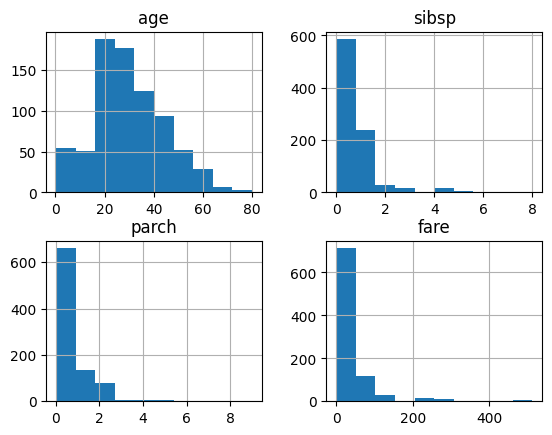

In [13]:
df_train.hist()
plt.show()

ANALISIS UNIVRIADO DE LAS VARIABLES CATEGORICAS

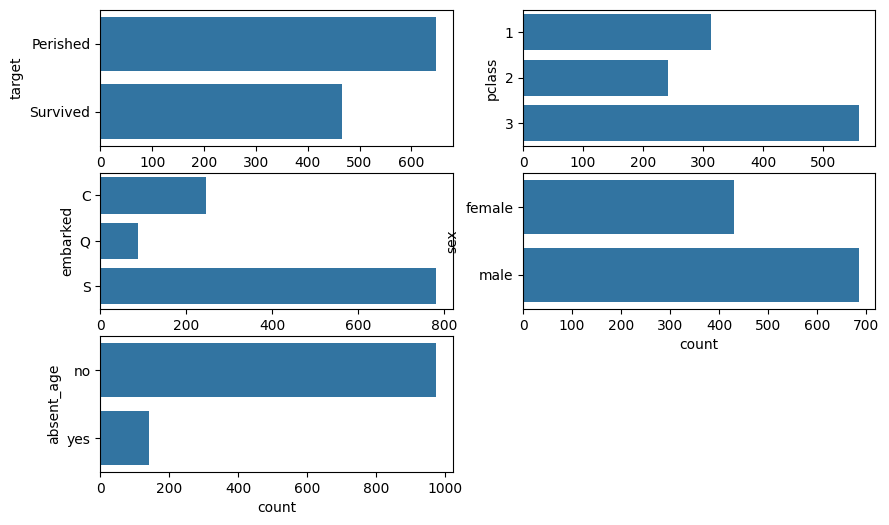

In [14]:
# Step 3.4 Univariate Analysis
fig, ax = plt.subplots(3, 2,  figsize= (10, 6))
sns.countplot(data= df, y= 'target', ax= ax[0, 0])
sns.countplot(data= df, y= 'pclass', ax= ax[0, 1])
sns.countplot(data= df, y= 'embarked', ax= ax[1, 0])
sns.countplot(data= df, y= 'sex', ax= ax[1, 1])
sns.countplot(data= df, y= 'absent_age', ax= ax[2, 0])
fig.delaxes(ax[2, 1])
plt.show()

ANALISIS BIVARIADO

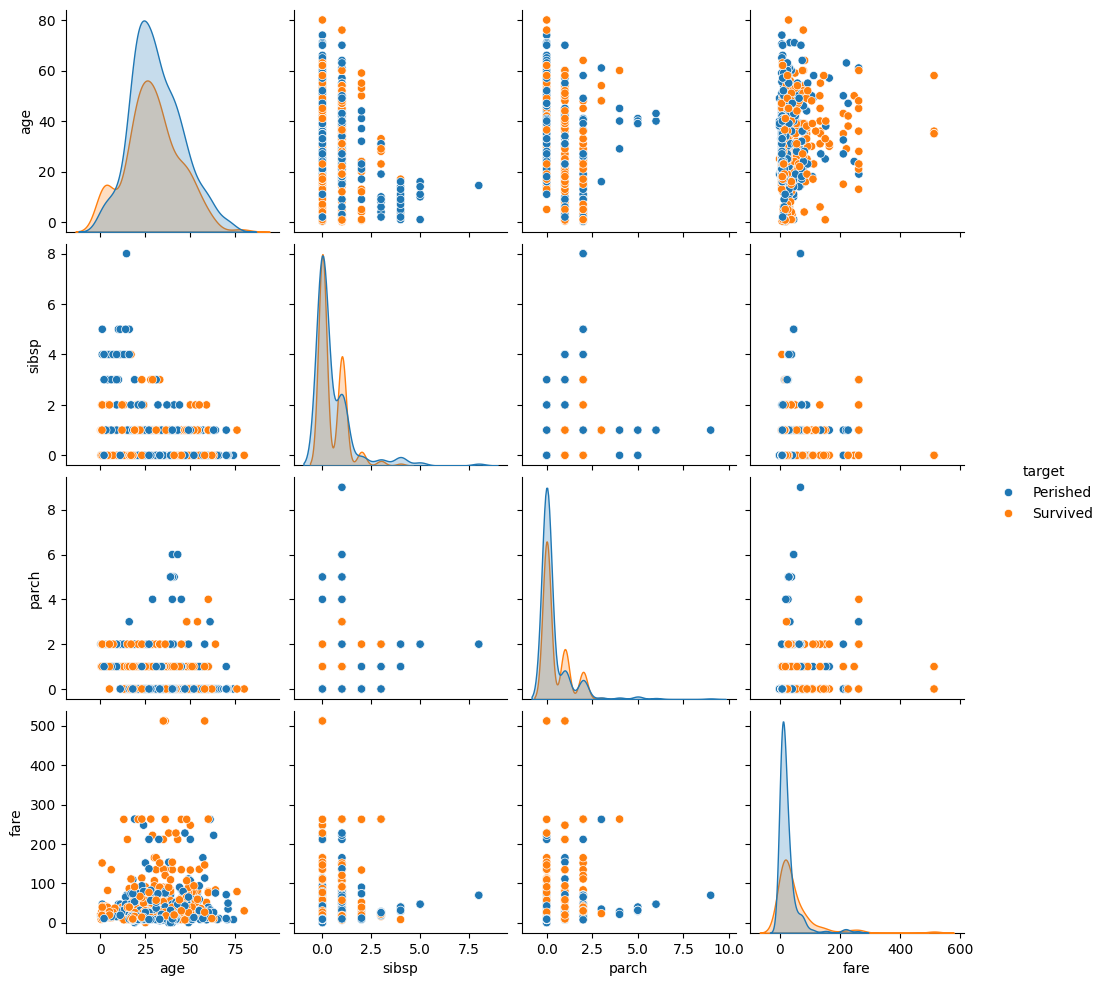

In [15]:
sns.pairplot(df_train, hue='target')
plt.show()

ANALISIS BIVARIADO DE LAS VARIABLES CATEGORICAS

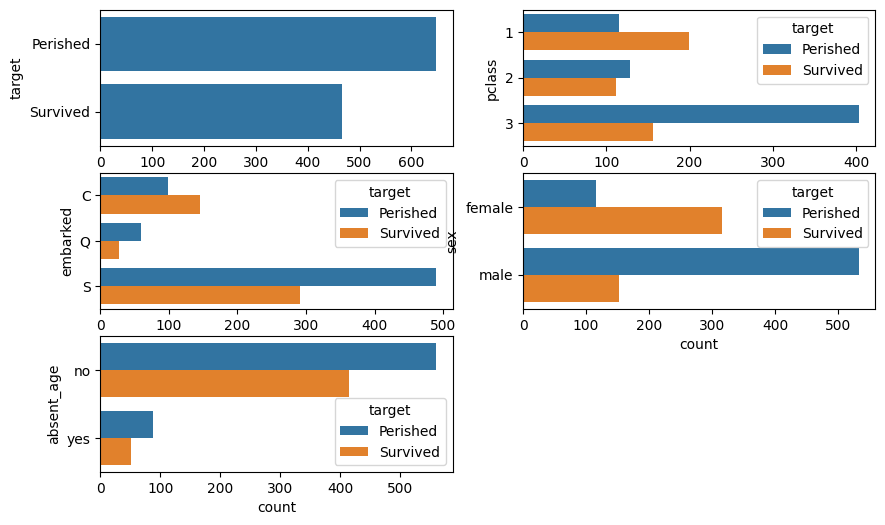

In [16]:
# Step 3.6 Bivariate Analysis for category
fig, ax = plt.subplots(3, 2,  figsize= (10, 6))
sns.countplot(data= df, y= 'target', ax= ax[0, 0])
sns.countplot(data= df, y= 'pclass', hue= 'target', ax= ax[0, 1])
sns.countplot(data= df, y= 'embarked', hue= 'target', ax= ax[1, 0])
sns.countplot(data= df, y= 'sex', hue= 'target', ax= ax[1, 1])
sns.countplot(data= df, y= 'absent_age', hue= 'target', ax= ax[2, 0])

# Eliminate fig ax[2,1], because we have 5 figs
fig.delaxes(ax[2, 1])
plt.show()

ANALISIS DE CORRELACIONES

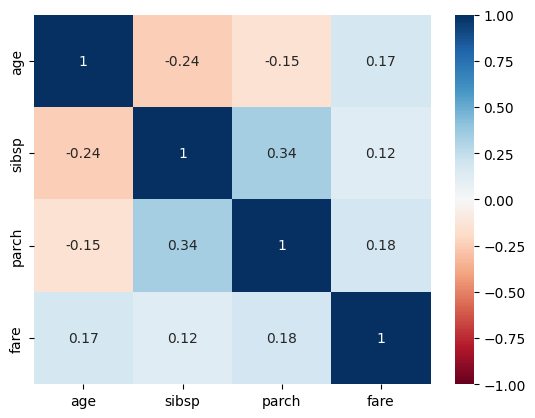

In [18]:
sns.heatmap(df_train.select_dtypes(include='number').corr(), vmin=-1, vmax=1, annot=True, cmap='RdBu')
plt.show()

ENTRENAMIENTO DE MODELO

In [23]:
# Step 4. Create a machine learning model
# 4.1 Split features and reponse
x_train = df_train.drop('target', axis=1).reset_index(drop=True)
y_train = df_train['target'].reset_index(drop=True)
x_test = df_test.drop('target', axis=1).reset_index(drop=True)
y_test = df_test['target'].reset_index(drop=True)

y_train.head()
x_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked,absent_age
0,1,male,24.0,0,1,247.5208,C,no
1,3,female,27.0,0,0,7.9250,S,no
2,1,male,37.0,0,1,29.7000,C,no
3,2,male,66.0,0,0,10.5000,S,no
4,1,female,27.0,1,2,52.0000,S,no


In [24]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)


In [27]:
y_train_enc_n = pd.Series(y_train_enc)
y_train_enc_n.head()

0    0
1    1
2    0
3    0
4    1
dtype: int64

In [28]:
cat_cols = x_train.select_dtypes(include='category').columns
num_cols = x_train.select_dtypes(include='number').columns



In [29]:
cat_proc = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown= 'ignore'))
])

num_proc = Pipeline([
    ('imputer', SimpleImputer(strategy= 'mean')),
    ('scaler',  MinMaxScaler())
])

procesor = ColumnTransformer(transformers= [
    ('cat', cat_proc, cat_cols),
    ('num', num_proc, num_cols)
])

In [31]:
procesor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [32]:
clf_tree = Pipeline(steps= [
    ('proc', procesor),
    ('tree', DecisionTreeClassifier(random_state=42)) # class_weight= 'balanced' para clases desbalanceada
])



In [33]:
clf_tree.fit(x_train, y_train_enc)

,steps,"[('proc', ...), ('tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
y_pred = clf_tree.predict(x_test)


In [36]:
accuracy = accuracy_score(y_test_enc, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7444


In [37]:
print(classification_report(y_test_enc, y_pred, target_names= label_encoder.classes_))

              precision    recall  f1-score   support

    Perished       0.77      0.80      0.78       130
    Survived       0.70      0.67      0.69        93

    accuracy                           0.74       223
   macro avg       0.74      0.73      0.73       223
weighted avg       0.74      0.74      0.74       223



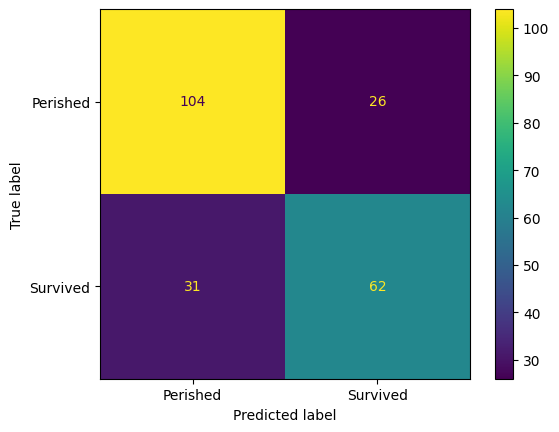

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred, 
                                        display_labels= label_encoder.classes_)
plt.show()

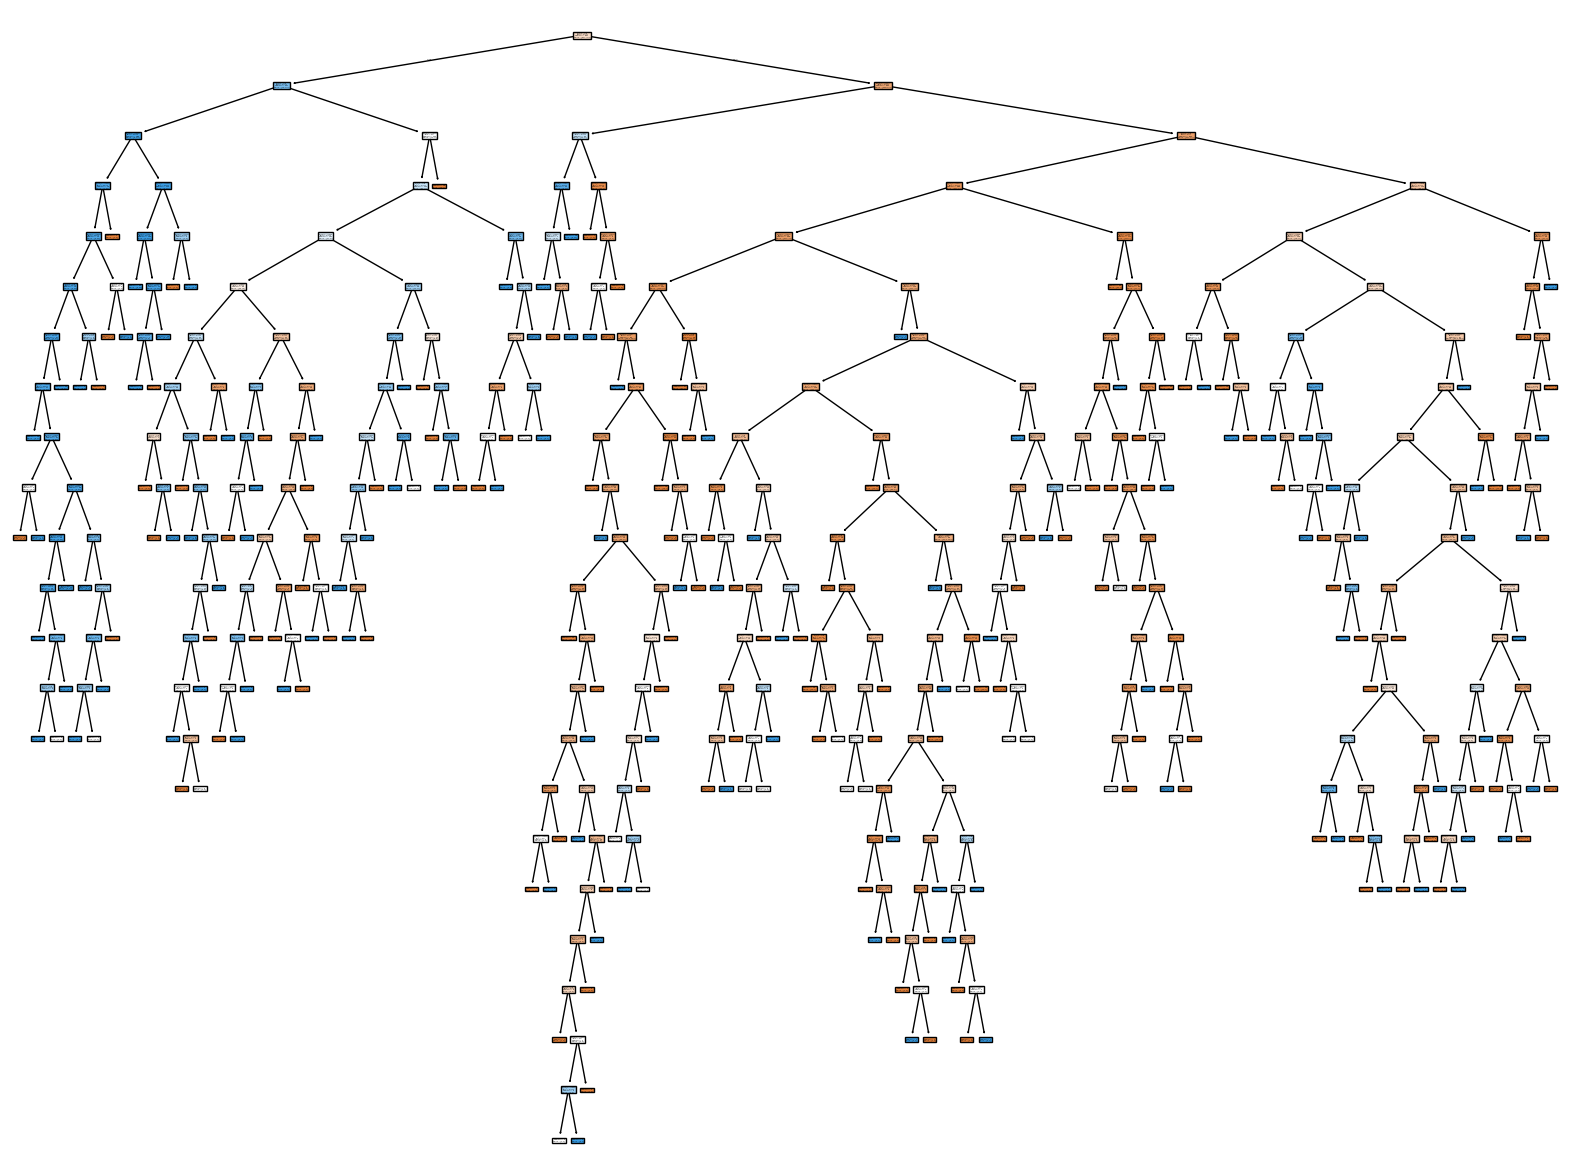

In [42]:
mi_arbol = clf_tree.named_steps['tree']
plt.figure(figsize=(20,15))
plot_tree(mi_arbol, 
          filled= True)
plt.show()